In [1]:
# Block 0 - Setup + imports + config
!pip install -q timm scikit-learn tqdm gradio==3.44.0

from pathlib import Path
import os, time, random, io, base64
import numpy as np
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tqdm import tqdm

# Config - EDIT if needed
DATASET_DIR = Path("/kaggle/input/plumbago-and-not-plumbago/LeafDataset")
SAVE_MODEL_PATH = Path("/kaggle/working/fusion_model.pth")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0   # safe for Kaggle to avoid worker/CUDA fork errors
BATCH_SIZE = 24
IMG_SIZE = 224
VAL_RATIO = 0.15
TEST_RATIO = 0.15
EPOCHS = 6
LR = 2e-4
FREEZE_BACKBONES = True   # train head only (fast)
SEED = 42

# Reproducible-ish
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("Device:", DEVICE)
print("Dataset root exists:", DATASET_DIR.exists())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 78.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.2/298.2 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 69.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.6/130.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
Dataset root exists: True


In [2]:
# Block 1 - collect samples and print counts
assert DATASET_DIR.exists(), f"Dataset dir not found: {DATASET_DIR}. Place your LeafDataset there."

plum_dir = DATASET_DIR / "Plumbago Zeylanica"
not_plum_dir = DATASET_DIR / "Not Plumbago Zeylanica"

if not plum_dir.exists():
    raise RuntimeError(f"Plumbago folder missing at {plum_dir}")
if not not_plum_dir.exists():
    raise RuntimeError(f"Not Plumbago folder missing at {not_plum_dir}")

samples = []
# Plumbago label 0
for p in plum_dir.rglob("*"):
    if p.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".tif",".tiff"]:
        samples.append((str(p), 0))
# Not Plumbago label 1 (merge subfolders)
for sub in not_plum_dir.iterdir():
    if not sub.is_dir():
        # if images directly inside not_plum_dir
        if sub.suffix.lower() in [".jpg",".jpeg",".png",".bmp"]:
            samples.append((str(sub),1))
        continue
    for p in sub.rglob("*"):
        if p.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".tif",".tiff"]:
            samples.append((str(p), 1))

if len(samples) == 0:
    raise RuntimeError("No images found. Check dataset layout.")

random.shuffle(samples)
N = len(samples)
n_test = int(N * TEST_RATIO)
n_val  = int(N * VAL_RATIO)
n_train = N - n_val - n_test

train = samples[:n_train]
val   = samples[n_train:n_train+n_val]
test  = samples[n_train+n_val:]

print("Total images:", N)
print("Train:", len(train), "Val:", len(val), "Test:", len(test))

Total images: 5222
Train: 3656 Val: 783 Test: 783


In [4]:
# Block 2 - transforms and dataset with masking crop
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(0.12,0.12,0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

def leaf_mask_from_pil(pil_img):
    # Fast color distance from green in HSV; returns binary 0/1 mask (H x W)
    try:
        img = np.array(pil_img.convert("RGB"))
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)
        # green hue roughly between 25 and 100 in OpenCV hue scale (0-179)
        mask1 = cv2.inRange(hsv, (25, 30, 20), (100, 255, 255))
        # also consider high saturation (colored leaf photos)
        mask = mask1
        # morphological clean
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        mask = (mask > 0).astype(np.uint8)
        return mask
    except Exception:
        # fallback: full image mask
        h, w = pil_img.size[1], pil_img.size[0]
        return np.ones((h,w), dtype=np.uint8)

class LeafDataset(Dataset):
    def __init__(self, samples, transform, crop_leaf=True):
        self.samples = samples
        self.transform = transform
        self.crop_leaf = crop_leaf

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p, label = self.samples[idx]
        try:
            pil = Image.open(p).convert("RGB")
        except Exception as e:
            pil = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0,0,0))
        if self.crop_leaf:
            mask = leaf_mask_from_pil(pil)
            ys, xs = np.where(mask > 0)
            if len(xs) > 0 and len(ys) > 0:
                x0, x1 = max(xs.min()-10, 0), min(xs.max()+10, mask.shape[1]-1)
                y0, y1 = max(ys.min()-10, 0), min(ys.max()+10, mask.shape[0]-1)
                try:
                    pil = pil.crop((x0, y0, x1, y1))
                except Exception:
                    pass
            # else: keep full image
        img_t = self.transform(pil)
        return img_t, int(label)


In [5]:
# Block 3 - dataloaders
NUM_WORKERS = 0
train_ds = LeafDataset(train, train_transform, crop_leaf=True)
val_ds   = LeafDataset(val, eval_transform, crop_leaf=True)
test_ds  = LeafDataset(test, eval_transform, crop_leaf=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Loaders created. Train batches:", len(train_loader), "Val batches:", len(val_loader), "Test batches:", len(test_loader))
# sanity batch
x,y = next(iter(train_loader))
print("Sanity batch shapes:", x.shape, y.shape)


Loaders created. Train batches: 153 Val batches: 33 Test batches: 33
Sanity batch shapes: torch.Size([24, 3, 224, 224]) torch.Size([24])


In [6]:
# Block 4 - build fusion model
device = DEVICE

def build_backbone(name):
    return timm.create_model(name, pretrained=True, num_classes=0, global_pool='avg')

print("Building backbones (may download weights)...")
eff = build_backbone("efficientnet_b0").to(device)
res = build_backbone("resnet50").to(device)
vit = build_backbone("vit_base_patch16_224").to(device)

# feature dims
d1 = getattr(eff, "num_features", None) or 1280
d2 = getattr(res, "num_features", None) or 2048
d3 = getattr(vit, "num_features", None) or 768
TOTAL_DIM = d1 + d2 + d3
print("Feature dims:", d1, d2, d3, "TOTAL:", TOTAL_DIM)

class FusionNet(nn.Module):
    def __init__(self, eff, res, vit, total_dim, num_classes=2):
        super().__init__()
        self.eff = eff
        self.res = res
        self.vit = vit
        self.head = nn.Sequential(
            nn.Linear(total_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        f1 = self.eff(x)
        f2 = self.res(x)
        f3 = self.vit(x)
        if f1.ndim==4: f1 = f1.mean(dim=(2,3))
        if f2.ndim==4: f2 = f2.mean(dim=(2,3))
        if f3.ndim==4: f3 = f3.mean(dim=(2,3))
        fusion = torch.cat([f1,f2,f3], dim=1)
        return self.head(fusion)

model = FusionNet(eff, res, vit, TOTAL_DIM, num_classes=2).to(device)
print("Model built. Parameters:", sum(p.numel() for p in model.parameters()))
if FREEZE_BACKBONES:
    for p in model.eff.parameters(): p.requires_grad=False
    for p in model.res.parameters(): p.requires_grad=False
    for p in model.vit.parameters(): p.requires_grad=False
    print("Backbones frozen (training head only).")


Building backbones (may download weights)...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Unexpected keys (norm.bias, norm.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Feature dims: 1280 2048 768 TOTAL: 4096
Model built. Parameters: 115412926
Backbones frozen (training head only).


In [8]:
# Block 5 - training utilities
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

def evaluate(loader):
    model.eval()
    preds = []; labs = []; loss_sum = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss_sum += criterion(out, yb).item()
            p = out.argmax(1).cpu().numpy()
            preds.extend(p)
            labs.extend(yb.cpu().numpy())
    acc = accuracy_score(labs, preds)
    pr, rc, f1, _ = precision_recall_fscore_support(labs, preds, average="binary", zero_division=0)
    return loss_sum / max(1, len(loader)), acc, pr, rc, f1

In [9]:
# Block 6 - training loop
best_val_f1 = -1.0
history = {"train_loss":[], "val_loss":[], "val_acc":[], "val_f1":[]}
for epoch in range(EPOCHS):
    model.train()
    running = 0.0; nb = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running += loss.item(); nb += 1
        if nb % 20 == 0:
            pbar.set_postfix({'avg_loss': running/nb})
    train_loss = running / max(1, nb)
    val_loss, val_acc, pr, rc, f1 = evaluate(val_loader)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc); history["val_f1"].append(f1)
    print(f"\nEpoch {epoch+1} summary - Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  Val F1: {f1:.4f}")
    # Save best by val F1
    if f1 > best_val_f1:
        best_val_f1 = f1
        torch.save(model.state_dict(), str(SAVE_MODEL_PATH))
        print("Saved best model to", SAVE_MODEL_PATH)


Epoch 1/6: 100%|██████████| 153/153 [08:00<00:00,  3.14s/it, avg_loss=0.0325]



Epoch 1 summary - Train Loss: 0.0299  Val Loss: 0.0010  Val Acc: 1.0000  Val F1: 1.0000
Saved best model to /kaggle/working/fusion_model.pth


Epoch 2/6: 100%|██████████| 153/153 [06:49<00:00,  2.68s/it, avg_loss=0.000854]



Epoch 2 summary - Train Loss: 0.0008  Val Loss: 0.0003  Val Acc: 1.0000  Val F1: 1.0000


Epoch 3/6: 100%|██████████| 153/153 [06:59<00:00,  2.74s/it, avg_loss=0.000288]


...


Epoch 4 summary - Train Loss: 0.0003  Val Loss: 0.0001  Val Acc: 1.0000  Val F1: 1.0000


Epoch 5/6: 100%|██████████| 153/153 [07:13<00:00,  2.84s/it, avg_loss=0.000266]



Epoch 5 summary - Train Loss: 0.0003  Val Loss: 0.0001  Val Acc: 1.0000  Val F1: 1.0000


Epoch 6/6: 100%|██████████| 153/153 [06:51<00:00,  2.69s/it, avg_loss=5.9e-5] 



Epoch 6 summary - Train Loss: 0.0001  Val Loss: 0.0000  Val Acc: 1.0000  Val F1: 1.0000


Loaded best model from /kaggle/working/fusion_model.pth

=== FINAL TEST METRICS ===
Test Loss: 0.0008
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1:        1.0000


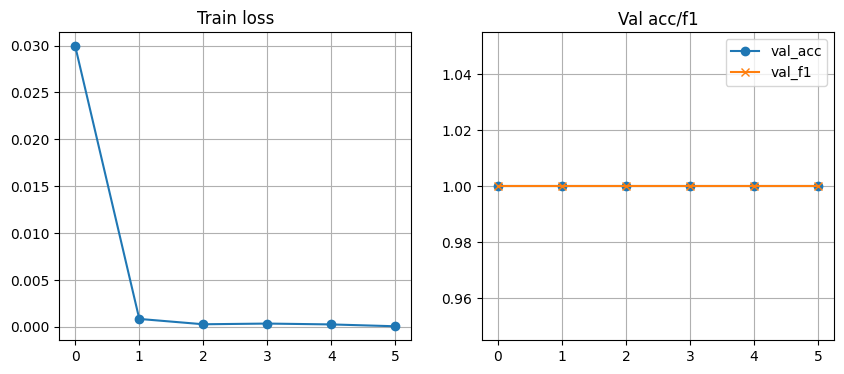

In [10]:
# Block 7 - load best and evaluate on test
if SAVE_MODEL_PATH.exists():
    model.load_state_dict(torch.load(SAVE_MODEL_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded best model from", SAVE_MODEL_PATH)
else:
    print("No saved model found; using current model state.")

test_loss, test_acc, test_pr, test_rc, test_f1 = evaluate(test_loader)
print("\n=== FINAL TEST METRICS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_pr:.4f}")
print(f"Recall:    {test_rc:.4f}")
print(f"F1:        {test_f1:.4f}")

# Plot training curves
try:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], marker='o'); plt.title("Train loss"); plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(history["val_acc"], marker='o', label='val_acc'); plt.plot(history["val_f1"], marker='x', label='val_f1'); plt.legend(); plt.title("Val acc/f1"); plt.grid(True)
    plt.show()
except Exception as e:
    print("Plot failed:", e)

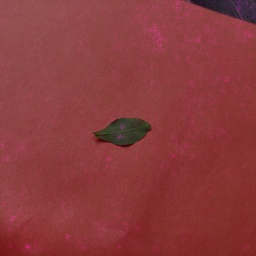

Explanation: attention spread across leaf surface; 3277 high-attention spot(s) detected (possible lesions/discoloration)


In [11]:
# Block 8 - saliency functions and demo on single test image
def tensor_from_pil(pil_img):
    t = eval_transform(pil_img).unsqueeze(0).to(device)
    return t

def gradient_saliency(model_obj, pil_img, target_class=None):
    model_obj.eval()
    x = tensor_from_pil(pil_img)
    x.requires_grad_()
    out = model_obj(x)
    if target_class is None:
        target_class = int(out.argmax(1).item())
    score = out[0, target_class]
    model_obj.zero_grad()
    score.backward()
    grads = x.grad.detach().cpu().numpy()[0]
    sal = np.abs(grads).sum(axis=0)
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal, target_class

def overlay_heat(orig_rgb, heatmap):
    h, w = orig_rgb.shape[:2]
    heat_r = cv2.resize(heatmap, (w,h))
    heat_color = np.zeros_like(orig_rgb)
    heat_color[:,:,2] = (heat_r*255).astype(np.uint8)
    heat_color[:,:,0] = (heat_r*255).astype(np.uint8)
    overlay = cv2.addWeighted(orig_rgb, 0.6, heat_color, 0.4, 0)
    return overlay, heat_r

def explain_from_heat(heat):
    h,w = heat.shape
    center = heat[h//4:3*h//4, w//4:3*w//4].mean()
    edges = np.concatenate([heat[:h//4,:].ravel(), heat[3*h//4:,:].ravel(), heat[:,:w//4].ravel(), heat[:,3*w//4:].ravel()]).mean()
    thr = np.percentile(heat, 95)
    hotspots = (heat >= thr).sum()
    parts = []
    if center > edges + 0.01:
        parts.append("focus on central veins / midrib")
    elif edges > center + 0.01:
        parts.append("focus on edges and contours (shape)")
    else:
        parts.append("attention spread across leaf surface")
    if hotspots >= 1:
        parts.append(f"{int(hotspots)} high-attention spot(s) detected (possible lesions/discoloration)")
    return "; ".join(parts)

# Demo on one test image (if available)
if len(test) > 0:
    demo_path, _ = test[0]
    pil = Image.open(demo_path).convert("RGB")
    sal, cls = gradient_saliency(model, pil)
    overlay, hr = overlay_heat(np.array(pil), sal)
    expl = explain_from_heat(hr)
    display(Image.fromarray(overlay))
    print("Explanation:", expl)

In [12]:
# Block 9 - optional Gradio UI
import gradio as gr

# load best model to CPU for UI (so you can close GPU session)
ui_model = FusionNet(eff, res, vit, TOTAL_DIM, num_classes=2).to("cpu")
if SAVE_MODEL_PATH.exists():
    ui_model.load_state_dict(torch.load(SAVE_MODEL_PATH, map_location="cpu"))
    ui_model.eval()
else:
    print("Saved model not found. UI will use current model (might be untrained).")

def predict_and_explain(pil_img):
    # crop using same crop function (fast)
    mask = leaf_mask_from_pil(pil_img)
    ys, xs = np.where(mask>0)
    if len(xs)>0:
        x0, x1 = max(xs.min()-10,0), min(xs.max()+10, mask.shape[1]-1)
        y0, y1 = max(ys.min()-10,0), min(ys.max()+10, mask.shape[0]-1)
        try:
            pil_crop = pil_img.crop((x0,y0,x1,y1))
        except:
            pil_crop = pil_img
    else:
        pil_crop = pil_img

    inp = transforms.Resize((IMG_SIZE,IMG_SIZE))(pil_crop)
    # forward
    t = transforms.Normalize(mean,std)(transforms.ToTensor()(inp)).unsqueeze(0)
    out = ui_model(t)
    probs = F.softmax(out, dim=1).detach().numpy()[0]
    pred = int(out.argmax(1).item()); conf = float(probs[pred])
    label = "Plumbago" if pred==0 else "Not Plumbago"
    # xai saliency - run on CPU model for UI
    # convert pil_crop -> numpy for overlay
    sal, _ = gradient_saliency(ui_model.to(device if device.type!='cpu' else "cpu"), pil_crop, target_class=pred)
    # if UI runs on CPU this will be computed on cpu. For safety, compute simple grad on ui_model currently on cpu
    if isinstance(sal, np.ndarray):
        ov, hr = overlay_heat(np.array(pil_crop), sal)
    else:
        ov, hr = np.array(pil_crop), np.zeros((pil_crop.size[1], pil_crop.size[0]))

    explanation = explain_from_heat(hr)
    # return image and texts
    return ov, f"{label} ({conf*100:.1f}%)", explanation

iface = gr.Interface(fn=predict_and_explain,
                     inputs=gr.Image(type="pil"),
                     outputs=[gr.Image(type="numpy", label="Overlay"), gr.Textbox(label="Prediction"), gr.Textbox(label="Explanation")],
                     title="Plumbago fusion XAI demo")
print("To show the UI in Kaggle you may need to run locally or deploy to Hugging Face Spaces. Run iface.launch() to start.")
# To launch (in coloc, you can set share=True but Kaggle may block public link):
# iface.launch(share=True)

To show the UI in Kaggle you may need to run locally or deploy to Hugging Face Spaces. Run iface.launch() to start.
IMPORTANT: You are using gradio version 3.44.0, however version 4.44.1 is available, please upgrade.
--------
